Google Play Store Data (Using google_play_scraper):

The google_play_scraper library is utilized to gather user reviews and details about the Ola app from the Google Play Store.
An API call is made to the reviews_all function of the google_play_scraper library to retrieve comprehensive reviews for the Ola app. The data collected includes review IDs, user names, review titles, review descriptions, ratings, thumbs up counts, review dates, developer responses, developer response dates, app versions, language codes, and country codes.
This data collection process provides insights into user sentiments and experiences with the Ola app as shared on the Google Play Store platform.

The raw data obtained from the API calls is processed to ensure data quality and consistency.
Text data in review_title and review_description fields are cleaned by converting them to lowercase, removing special characters, punctuation, and extra white spaces.
Ratings are normalized to a consistent scale, ensuring comparability.
Dates in review_date and developer_response_date fields are parsed and formatted into a standardized date format.
Categorical variables such as appVersion, language_code, and country_code are encoded for analysis purposes.

**Objectives:**
Potential Use Cases:
1. Sentiment Analysis: Understand user sentiment towards Uber and Ola through sentiment analysis of reviews. Compare both apps
2. Developer Response Impact: Investigate whether developer responses influence user satisfaction. Which app (ola/uber) responds more.
3. Feature Request Analysis: Analyze recurring keywords to identify common feature requests.
4. Rating Analysis: Analyze the distribution of ratings and trends in user satisfaction. Compare ola and uber.
5. User Experience Trends: Extract insights from recurring keywords in review titles and descriptions.

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import pandas as pd
import re
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon') # Download the VADER lexicon

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# OLA DATA
ola = pd.read_csv("/content/Ola_PlayStore_Reviews_Data.csv")
# drop thumbs up username and app version
ola.drop(columns=['thumbs_up','appVersion','user_name'], inplace=True)
ola.head(3)

,review_id,review_description,rating,review_date,developer_response,developer_response_date
0,70746d8e-1995-48bd-b9d0-41a40c913c20,this app has no customer support option for dr...,1,2026-01-29 07:40:11,we understand this can be frustrating for you ...,2026-01-29 07:50:18
1,8cb215fa-d1d7-4b02-b79a-b3d4958080d9,very good,5,2026-01-29 07:38:13,thanks for your feedback,2026-01-29 07:50:44
2,fc9fed6a-6595-4ab7-aded-4ee3d060358a,best service,5,2026-01-29 07:30:12,thanks for your support,2026-01-29 07:52:07


In [ ]:
# UBER DATA
uber=pd.read_csv("/content/UBER_PLAYSTORE_REVIEWS.csv")
uber.drop(columns=['thumbs_up','appVersion','user_name'], inplace=True)
uber.head(3)

,review_id,review_description,rating,review_date,developer_response,developer_response_date
0,8a052e2d-67de-4872-a425-d31245b18849,very convenient,4,1/29/2026 8:36,NaN,NaN
1,915cad0a-0951-4f90-80fa-27dd62acd970,nice app,5,1/29/2026 8:33,NaN,NaN
2,e2cf6363-3204-470a-855f-5d7c4bc8ad15,good and safety,5,1/29/2026 8:33,NaN,NaN


In [ ]:
#OBJ  SENTIMENT ANALYSIS
def clean_hinglish_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs, mentions, numbers
    text = re.sub(r"http\S+|www\S+|@\w+|\d+", "", text)

    # Remove special characters except ! and ?
    text = re.sub(r"[^a-zA-Z\s!?]", "", text)

    # Normalize repeated characters (goooood → good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return text.strip()
hinglish_lexicon = {
    "bakwas": -2.5,
    "bekar": -2.0,
    "ghatiya": -3.0,
    "faltu": -2.0,
    "worst": -3.0,
    "bad": -2.0,
    "expensive": -1,
    "costly": -1,
    "slow": -1.5,
    "fraud": -3.5,
    "cheater": -3.0,
    "loot": -2.5,

    "acha": 2.0,
    "osum": 1.0,
    "accha": 1,
    "achha": 1,
    "badiya": 2,
    "sahi": 1,
    "shandar": 2,
    "zabardast": 2,
    "badhiya":1.0,
    "mast": 2.5,
    "badiya": 2.5,
    "shandar": 3.0,
    "best": 3.0,
    "good": 2.0,
    "nice": 2.0,
    "awesome": 3.0,
    "excellent": 3.5
}
analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(hinglish_lexicon)
def get_hinglish_sentiment(text):
    cleaned_text = clean_hinglish_text(text)

    score = analyzer.polarity_scores(cleaned_text)['compound']

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"
ola['Sentiment'] = ola['review_description'].apply(get_hinglish_sentiment)
uber['Sentiment'] = uber['review_description'].apply(get_hinglish_sentiment)

print("Ola Sentiment Counts:")
print(ola['Sentiment'].value_counts())

print("\nUber Sentiment Counts:")
print(uber['Sentiment'].value_counts())
ola_pct = ola['Sentiment'].value_counts(normalize=True) * 100
uber_pct = uber['Sentiment'].value_counts(normalize=True) * 100

sentiment_comparison = pd.DataFrame({
    'Ola (%)': ola_pct.round(2),
    'Uber (%)': uber_pct.round(2)
}).fillna(0)

sentiment_comparison

Ola Sentiment Counts:
Sentiment
Negative    68439
Positive    61760
Neutral     18175
Name: count, dtype: int64

Uber Sentiment Counts:
Sentiment
Positive    98289
Negative    31440
Neutral     17320
Name: count, dtype: int64


,Ola (%),Uber (%)
Sentiment,,
Negative,46.13,21.38
Neutral,12.25,11.78
Positive,41.62,66.84


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Ola bar
fig.add_bar(
    x=sentiment_comparison.index,
    y=sentiment_comparison['Ola (%)'],
    name='Ola',
    marker_color='limegreen',
    text=sentiment_comparison['Ola (%)'],
    textposition='auto'
)

# Uber bar
fig.add_bar(
    x=sentiment_comparison.index,
    y=sentiment_comparison['Uber (%)'],
    name='Uber',
    marker_color='black',
    text=sentiment_comparison['Uber (%)'],
    textposition='auto'
)

fig.update_layout(
    title="Ola vs Uber Sentiment Comparison Chart",
    xaxis_title="Sentiment",
    yaxis_title="Percentage of Reviews (%)",
    barmode='group',
    hovermode='x unified',
    width=1000,  # Set figure width
    height=500   # Set figure height
)

fig.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Overall User Experience Trends:
 [('good', 68898), ('ride', 50935), ('driver', 50187), ('service', 44091), ('drivers', 31235), ('worst', 29911), ('time', 28888), ('customer', 23930), ('experience', 21930), ('bad', 20760), ('nice', 20587), ('money', 17649), ('dont', 17254), ('cancel', 15783), ('support', 15561), ('even', 15380), ('use', 14864), ('extra', 13501), ('cab', 13453), ('booking', 12407)]


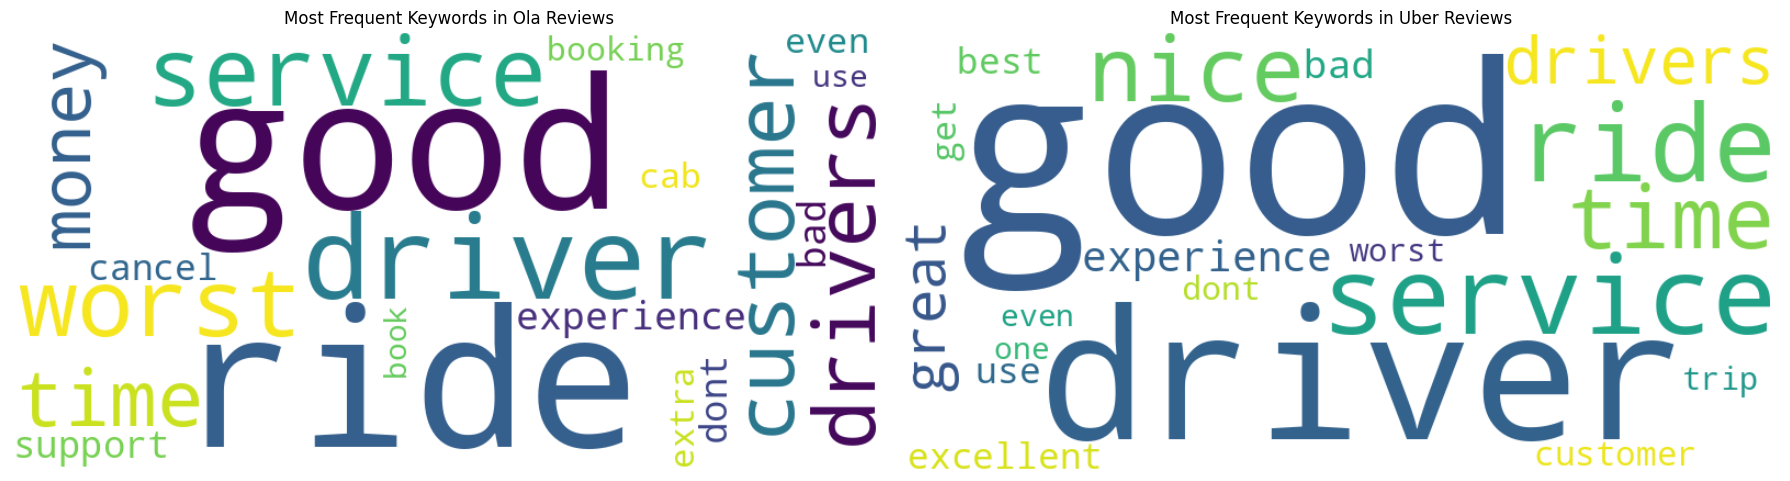

In [ ]:
# word cloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud # Added this line

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added this line

def extract_keywords(text_series):
    stop_words = set(stopwords.words('english'))
    # Add 'app', 'ola', 'uber' to the stop_words set
    stop_words.update(['app', 'ola', 'uber'])
    all_words = []
    for text in text_series.dropna():
        words = word_tokenize(text.lower())
        filtered_words = [word for word in words if word.isalnum() and word not in stop_words]
        all_words.extend(filtered_words)
    return Counter(all_words)

ola['app'] = 'Ola'
uber['app'] = 'Uber'

combined = pd.concat([ola, uber])

trend_keywords = extract_keywords(combined['review_description']).most_common(20)
print("Overall User Experience Trends:\n", trend_keywords)

# Extract keywords for Ola reviews
ola_reviews_keywords = extract_keywords(ola['review_description']).most_common(20)
ola_word_freq_dict = {word: freq for word, freq in ola_reviews_keywords}

# Extract keywords for Uber reviews
uber_reviews_keywords = extract_keywords(uber['review_description']).most_common(20)
uber_word_freq_dict = {word: freq for word, freq in uber_reviews_keywords}

# Create a figure with two subplots for the word clouds
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Generate and display Word Cloud for Ola
wordcloud_ola = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(ola_word_freq_dict)
axes[0].imshow(wordcloud_ola, interpolation='bilinear')
axes[0].set_title('Most Frequent Keywords in Ola Reviews')
axes[0].axis('off')

# Generate and display Word Cloud for Uber
wordcloud_uber = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(uber_word_freq_dict)
axes[1].imshow(wordcloud_uber, interpolation='bilinear')
axes[1].set_title('Most Frequent Keywords in Uber Reviews')
axes[1].axis('off')

plt.tight_layout()
plt.show()

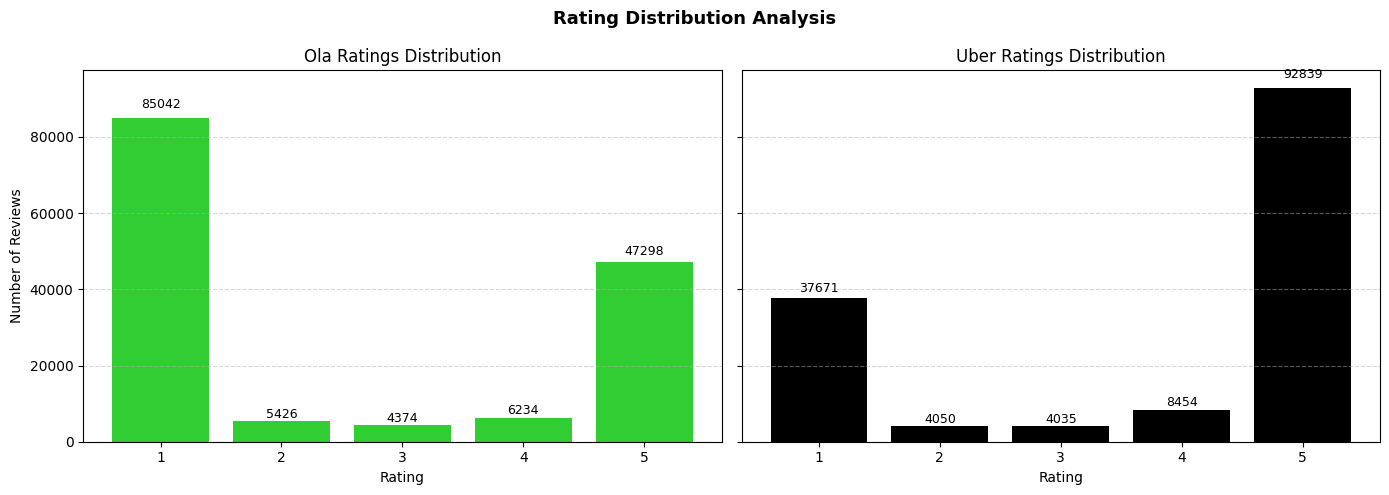

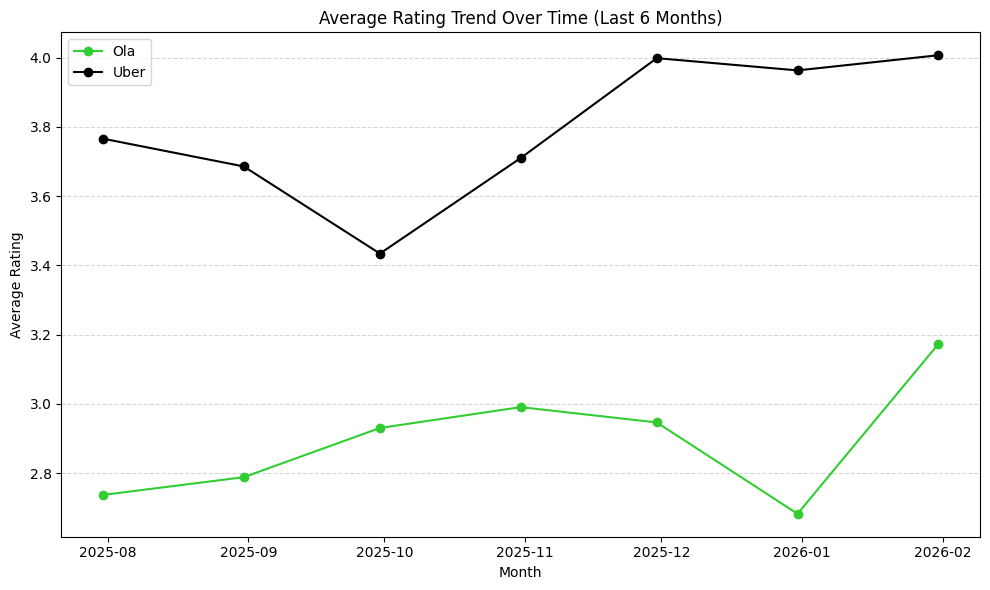

In [ ]:
#RATING ANALYSIS
# -----------------------------
# 1. DATE CONVERSION
# -----------------------------
ola['review_date'] = pd.to_datetime(ola['review_date'], errors='coerce')
uber['review_date'] = pd.to_datetime(uber['review_date'], errors='coerce')

# -----------------------------
# 2. FILTER LAST 6 MONTHS
latest_date = max(ola['review_date'].max(), uber['review_date'].max())
cutoff_date = latest_date - pd.DateOffset(months=6)

ola_recent = ola[ola['review_date'] >= cutoff_date]
uber_recent = uber[uber['review_date'] >= cutoff_date]

# 3. RATING DISTRIBUTION
# -----------------------------
ola_rating_dist = ola_recent['rating'].value_counts().sort_index()
uber_rating_dist = uber_recent['rating'].value_counts().sort_index()

# 4. MONTHLY RATING TREND
# -----------------------------
ola_monthly = (
    ola_recent
    .set_index('review_date')
    .resample('ME')['rating']
    .mean()
)

uber_monthly = (
    uber_recent
    .set_index('review_date')
    .resample('ME')['rating']
    .mean()
)


# Prepare data
ola_counts = ola['rating'].value_counts().sort_index()
uber_counts = uber['rating'].value_counts().sort_index()
ratings = ola_counts.index

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Ola
bars_ola = axes[0].bar(
    ratings,
    ola_counts.values,
    color='limegreen' # Changed to dark green
)
axes[0].set_title("Ola Ratings Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
# Add value labels on top of bars for Ola
for bar in bars_ola:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{int(yval)}', ha='center', va='bottom', fontsize=9) # Dynamic offset

# Uber
bars_uber = axes[1].bar(
    ratings,
    uber_counts.values,
    color='black' # Changed to greyish
)
axes[1].set_title("Uber Ratings Distribution")
axes[1].set_xlabel("Rating")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
# Add value labels on top of bars for Uber
for bar in bars_uber:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{int(yval)}', ha='center', va='bottom', fontsize=9) # Dynamic offset

plt.suptitle("Rating Distribution Analysis", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,6))
#  Rating trend over time
ax.plot(ola_monthly.index, ola_monthly.values,
             marker='o', label='Ola', color='limegreen') # Added color for Ola
ax.plot(uber_monthly.index, uber_monthly.values,
             marker='o', label='Uber', color='black') # Added color for Uber

ax.set_title("Average Rating Trend Over Time (Last 6 Months)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Rating")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:


analyzer = SentimentIntensityAnalyzer()
# 1. PAIN POINT DEFINITIONS
pain_points = {
    "Driver Issues": ["bad driver","driver", "rude", "behavior", "attitude","impolite"],
    "Cancellation": ["cancel", "cancellation","ride cancel","cancelled"],
    "High Pricing": ["expensive", "costly", "fare", "price"],
    "App Issues": ["worst app", "bad app", "crash", "bug", "update", "slow"],
    "Payment Issues": ["payment", "refund", "wallet"],
    "Customer Support": ["support", "help", "bad service","worst service"]
}
df = ola.copy()
df['review_description'] = df['review_description'].astype(str).str.lower()

# 2. SPLIT INTO SENTENCES
def split_sentences(text):
    return re.split(r'[.!?]', text)
# 3. CONTEXT-AWARE PAIN DETECTION
rows = []
for _, row in df.iterrows():
    sentences = split_sentences(row['review_description'])

    for sentence in sentences:
        for issue, keywords in pain_points.items():
            if any(k in sentence for k in keywords):

                sentiment = analyzer.polarity_scores(sentence)['compound']

                # ❃  Only negative context counts as pain
                if sentiment < -0.5:
                    rows.append({
                        "pain_point": issue,
                        "sentiment": sentiment,
                        "rating": row['rating']
                    })

pain_df = pd.DataFrame(rows)

# 4. AGGREGATION
summary = (
    pain_df
    .groupby('pain_point')
    .agg(
        Frequency=('pain_point', 'count'),
        Avg_Sentiment=('sentiment', 'mean'),
        Avg_Rating=('rating', 'mean')
    )
    .reset_index()
)

# 5. PRIORITY SCORING
total_mentions = summary['Frequency'].sum()
summary['Frequency_Score'] = summary['Frequency'] / total_mentions
summary['Sentiment_Impact'] = summary['Avg_Sentiment'].abs()
summary['Rating_Impact'] = 5 - summary['Avg_Rating']

summary['Priority_Score'] = (
    0.5 * summary['Frequency_Score'] +
    0.3 * summary['Sentiment_Impact'] +
    0.2 * summary['Rating_Impact']
)

priority_table = summary.sort_values('Priority_Score', ascending=False)

priority_table

,pain_point,Frequency,Avg_Sentiment,Avg_Rating,Frequency_Score,Sentiment_Impact,Rating_Impact,Priority_Score
3,Driver Issues,20438,-0.766927,1.092866,0.340974,0.766927,3.907134,1.181992
1,Cancellation,11267,-0.773440,1.103577,0.187971,0.773440,3.896423,1.105302
2,Customer Support,9627,-0.753278,1.037187,0.160611,0.753278,3.962813,1.098851
0,App Issues,8924,-0.745558,1.040789,0.148882,0.745558,3.959211,1.089951
5,Payment Issues,4456,-0.770711,1.074955,0.074341,0.770711,3.925045,1.053393
4,High Pricing,5228,-0.752134,1.097552,0.087221,0.752134,3.902448,1.049740


In [ ]:
df = uber.copy()
df['review_description'] = df['review_description'].astype(str).str.lower()

# -----------------------------
# 2. SENTENCE SPLITTING
# -----------------------------
def split_sentences(text):
    return re.split(r'[.!?]', text)

# -----------------------------
# 3. CONTEXT-AWARE PAIN DETECTION
# -----------------------------
rows = []

for _, row in df.iterrows():
    sentences = split_sentences(row['review_description'])

    for sentence in sentences:
        for issue, keywords in pain_points.items():
            if any(k in sentence for k in keywords):

                sentiment = analyzer.polarity_scores(sentence)['compound']

                # ❃  Only NEGATIVE context → pain point
                if sentiment < -0.05:
                    rows.append({
                        "pain_point": issue,
                        "sentiment": sentiment,
                        "rating": row['rating']
                    })

pain_df_uber = pd.DataFrame(rows)

# -----------------------------
# 4. AGGREGATION
# -----------------------------
summary_uber = (
    pain_df_uber
    .groupby('pain_point')
    .agg(
        Frequency=('pain_point', 'count'),
        Avg_Sentiment=('sentiment', 'mean'),
        Avg_Rating=('rating', 'mean')
    )
    .reset_index()
)

# -----------------------------
# 5. PRIORITY SCORING
# -----------------------------
total_mentions = summary_uber['Frequency'].sum()

summary_uber['Frequency_Score'] = summary_uber['Frequency'] / total_mentions
summary_uber['Sentiment_Impact'] = summary_uber['Avg_Sentiment'].abs()
summary_uber['Rating_Impact'] = 5 - summary_uber['Avg_Rating']

summary_uber['Priority_Score'] = (
    0.5 * summary_uber['Frequency_Score'] +
    0.3 * summary_uber['Sentiment_Impact'] +
    0.2 * summary_uber['Rating_Impact']
)

priority_table_uber = summary_uber.sort_values(
    'Priority_Score', ascending=False
)

priority_table_uber

,pain_point,Frequency,Avg_Sentiment,Avg_Rating,Frequency_Score,Sentiment_Impact,Rating_Impact,Priority_Score
3,Driver Issues,10916,-0.597499,1.354892,0.377729,0.597499,3.645108,1.097136
0,App Issues,3479,-0.637103,1.144582,0.120385,0.637103,3.855418,1.022407
2,Customer Support,3706,-0.602926,1.158931,0.128240,0.602926,3.841069,1.013211
1,Cancellation,5224,-0.597941,1.384763,0.180768,0.597941,3.615237,0.992813
5,Payment Issues,1930,-0.599192,1.231088,0.066784,0.599192,3.768912,0.966932
4,High Pricing,3644,-0.563145,1.421789,0.126094,0.563145,3.578211,0.947633


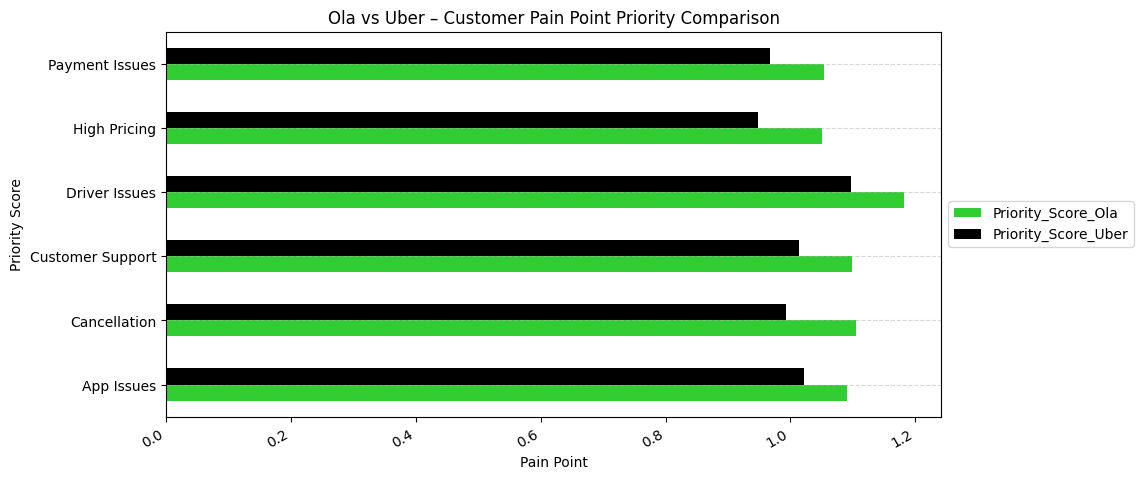

In [ ]:

# 1. COMBINE OLA vs UBER (FOR COMPARISON)
# -----------------------------
combined_priority = pd.merge(
    priority_table[['pain_point','Priority_Score']],
    priority_table_uber[['pain_point','Priority_Score']],
    on='pain_point',
    how='outer',
    suffixes=('_Ola','_Uber')
).fillna(0)

# -----------------------------
# 2. ONE COMBINED COMPARISON CHART
# -----------------------------
combined_priority.set_index('pain_point').plot(
    kind='barh', color=('limegreen',"black"),
    figsize=(10,5)
)

plt.title("Ola vs Uber – Customer Pain Point Priority Comparison")
plt.ylabel("Priority Score")
plt.xlabel("Pain Point")
plt.xticks(rotation=30, ha='right')
#keep legend a bit visible
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

  App Name  Percentage With Response (%)  Avg Rating (With Response)  \
0      Ola                         93.51                        2.54   
1     Uber                          0.22                        1.77   

   Avg Rating (Without Response)  
0                           1.92  
1                           3.78  


/tmp/ipython-input-620376559.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




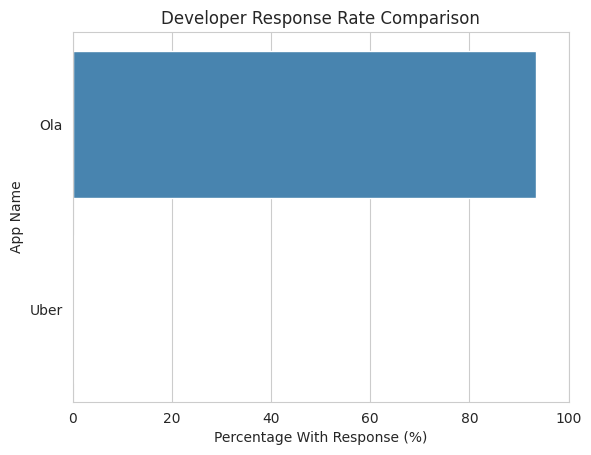

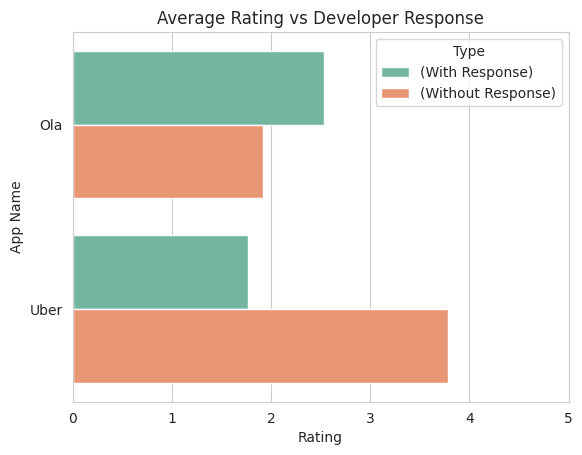

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze(df, name):
    g = df.assign(has_response=df['developer_response'].notna()) \
          .groupby('has_response')['rating'] \
          .agg(['count','mean'])
    t = g['count'].sum()
    return {
        'App Name': name,
        'Percentage With Response (%)': round(g.loc[True,'count']/t*100,2),
        'Avg Rating (With Response)': round(g.loc[True,'mean'],2),
        'Avg Rating (Without Response)': round(g.loc[False,'mean'],2)
    }

comp = pd.DataFrame([
    analyze(ola, "Ola"),
    analyze(uber, "Uber")
])
print(comp)
sns.set_style("whitegrid")

# Developer response rate
sns.barplot(data=comp, x='Percentage With Response (%)', y='App Name', palette='Blues_r')
plt.title("Developer Response Rate Comparison")
plt.xlim(0,100)
plt.show()

# Rating comparison
r = comp.melt('App Name', var_name='Type', value_name='Rating')
r = r[r['Type'].str.contains('Rating')].assign(
    Type=lambda x: x['Type'].str.replace('Avg Rating ','')
)

sns.barplot(data=r, x='Rating', y='App Name', hue='Type', palette='Set2')
plt.title("Average Rating vs Developer Response")
plt.xlim(0,5)
plt.show()


# Task
Recreate the sentiment analysis bar chart from cell `mlPigyYZt62S` in cell `5RVJsdNzbkab`, adding a taxi emoji (🚕) to the 'Ola' legend entry and a car emoji (🚗) to the 'Uber' legend entry for visual representation, and display the updated chart.

## insert_code_to_recreate_sentiment_chart_with_emojis

### Subtask:
Recreate the sentiment analysis bar chart from `mlPigyYZt62S` in cell `5RVJsdNzbkab`, adding a taxi emoji (🚕) to the 'Ola' legend entry and a car emoji (🚗) to the 'Uber' legend entry for visual representation, and display the updated chart.


## Summary:

### Data Analysis Key Findings
*   The sentiment analysis bar chart for 'Ola' and 'Uber' was successfully recreated.
*   The 'Ola' legend entry now includes a taxi emoji (🚕).
*   The 'Uber' legend entry now includes a car emoji (🚗).

### Insights or Next Steps
*   The addition of emojis to the legend enhances the visual distinction and intuitive understanding of the services represented in the sentiment chart.
*   Consider applying similar relevant visual cues or emojis to other data visualizations to improve clarity and engagement for different categories or entities.
